In [ ]:
!pip install -q fastapi uvicorn sqlalchemy pydantic email-validator pyngrok nest-asyncio requests passlib[bcrypt] python-jose

In [ ]:
# Main.py của tuần 15
# tạo database và model lại cho main.py
# sau đó tiếp tục chu trình Import thư viện, Dọn môi trường, Đăng nhập ngrok, Chạy FastAPI, Đợi server sẵn sàng,
# Kiểm tra localhost, Mở ngrok, Test từ Internet và cuối cùng nếu cần thay đổi lại main.py chỉ cần đến khu vực xóa bỏ.
# CREATE USER (API đầu tiên)

%%writefile main.py
# =========== Thêm import  ==================== #
from fastapi import FastAPI
from fastapi import Depends
from fastapi import HTTPException
from fastapi import Query
from jose import jwt
from jose import JWTError
from fastapi.security import OAuth2PasswordBearer
from datetime import datetime
from datetime import timedelta
from sqlalchemy.exc import IntegrityError
from typing import Optional, Any

from pydantic import (
    BaseModel,
    ConfigDict,
    EmailStr,
    Field
)

from sqlalchemy import (
    create_engine,
    Column,
    Integer,
    String
)

from sqlalchemy.orm import (
    declarative_base,
    sessionmaker,
    Session
)


from passlib.context import CryptContext


app = FastAPI(
    title="FastAPI CRUD",
    version="0.2.0"
)

pwd_context = CryptContext(
    schemes=["bcrypt"],
    deprecated="auto"
)

# Production:
# SECRET_KEY nên lấy từ Environment Variable
SECRET_KEY = "my_super_secret_key"

ALGORITHM = "HS256"

ACCESS_TOKEN_EXPIRE_MINUTES = 120

oauth2_scheme = OAuth2PasswordBearer(
    tokenUrl="login"
)

def hash_password(password: str):
    return pwd_context.hash(password)

def verify_password(
    plain_password: str,
    hashed_password: str
):
    return pwd_context.verify(
        plain_password,
        hashed_password
    )

def create_access_token(data: dict):

    to_encode = data.copy()

    expire = datetime.utcnow() + timedelta(
        minutes=ACCESS_TOKEN_EXPIRE_MINUTES
    )

    to_encode.update(
        {
            "exp": expire
        }
    )

    return jwt.encode(
        to_encode,
        SECRET_KEY,
        algorithm=ALGORITHM
    )

def decode_access_token(token: str):

    try:

        payload = jwt.decode(
            token,
            SECRET_KEY,
            algorithms=[ALGORITHM]
        )

        return payload

    except JWTError:

        raise HTTPException(
            status_code=401,
            detail="Invalid token"
        )

def get_current_user(

    token: str = Depends(oauth2_scheme)

):

    payload = decode_access_token(token)

    email = payload.get("sub")

    if email is None:

        raise HTTPException(
            status_code=401,
            detail="Invalid token"
        )

    return email


# RESPONSE FORMAT
def response(message: str, data=None):
    return {
        "status": "success",
        "message": message,
        "data": data
    }


# ==========================
# Database Configuration
# ==========================

DATABASE_URL = "sqlite:///./user.db"

engine = create_engine(
    DATABASE_URL,
    connect_args={"check_same_thread": False}
)

SessionLocal = sessionmaker(
    autocommit=False,
    autoflush=False,
    bind=engine
)

Base = declarative_base()

# ==========================
# SQLAlchemy Model
# ==========================

class User(Base):

    __tablename__ = "users"

    id = Column(Integer, primary_key=True, index=True)

    name = Column(String(100), nullable=False)

    email = Column(String(100), unique=True, nullable=False)

    role = Column(String(100), nullable=False)

    password = Column(String(255), nullable=False)

# ==========================
# Pydantic Schemas    -----------  Tạo Schema --------------
# ==========================
class UserCreate(BaseModel):

    name: str = Field(
        min_length=2,
        max_length=100
    )

    email: EmailStr

    role: str = Field(
        min_length=2,
        max_length=30
    )

    password: str = Field(
        min_length=6
    )

class UserUpdate(BaseModel):

    name: str = Field(
        min_length=2,
        max_length=100
    )

    email: EmailStr

    role: str = Field(
        min_length=2,
        max_length=30
    )

class UserPatch(BaseModel):

    name: Optional[str] = Field(
        default=None,
        min_length=2,
        max_length=100
    )

    email: Optional[EmailStr] = None

    role: Optional[str] = Field(
        default=None,
        min_length=2,
        max_length=30
    )

class LoginRequest(BaseModel):

    email: EmailStr

    password: str

class UserResponse(BaseModel):
    id: int
    name: str
    email: str
    role: str

    model_config = ConfigDict(from_attributes=True)

class TokenResponse(BaseModel):

    access_token: str

    token_type: str

class APIResponse(BaseModel):
    status: str
    message: str
    data: Any | None = None


# ==========================
# Tạo database và table
# ==========================

Base.metadata.create_all(bind=engine)

def get_db():

    db = SessionLocal()

    try:

        yield db

    finally:

        db.close()

# ==========================
# API
# ==========================

@app.get("/")
def root():

    return response(
    "FastAPI is running",
    {
        "version":"0.2.0",
        "database":"SQLite",
        "status":"Healthy"
    }
)

@app.post("/users/", response_model=APIResponse)
def create_user(user: UserCreate, db: Session = Depends(get_db)):

    # kiểm tra email trùng
    existing_user = db.query(User).filter(User.email == user.email).first()

    if existing_user:
        raise HTTPException(status_code=409, detail="Email already exists")

    # tạo user mới
    new_user = User(
    name=user.name,
    email=user.email,
    role=user.role,
    password=hash_password(user.password)
)

    # lưu database
    try:
        db.add(new_user)

        db.commit()

        db.refresh(new_user)

    except IntegrityError:

        db.rollback()

        raise HTTPException(
            status_code=500,
            detail="Database error"
        )
    return response(
        "User created successfully",
        UserResponse.model_validate(new_user).model_dump()
    )

@app.post(
    "/login",
    response_model=TokenResponse
)
def login(
    request: LoginRequest,
    db: Session = Depends(get_db)
):

    user = db.query(User).filter(
        User.email == request.email
    ).first()

    if not user:

        raise HTTPException(
            status_code=401,
            detail="Invalid email or password"
        )

    if not verify_password(
        request.password,
        user.password
    ):

        raise HTTPException(
            status_code=401,
            detail="Invalid email or password"
        )

    access_token = create_access_token(
        {
            "sub": user.email
        }
    )

    return TokenResponse(
        access_token=access_token,
        token_type="bearer"
    )

@app.get("/users/", response_model=APIResponse)
def get_users(

    skip: int = Query(0, ge=0),

    limit: int = Query(
        10,
        ge=1,
        le=100
    ),

    search: str | None = Query(
        default=None,
        min_length=1,
        max_length=100

    ),

    db: Session = Depends(get_db)

):

    query = db.query(User)

    if search:
        query = query.filter(
            User.name.ilike(f"%{search}%")
        )

    users = query.offset(skip).limit(limit).all()

    data = [
        UserResponse.model_validate(user).model_dump()
        for user in users
    ]

    return response(
        "Users retrieved successfully",
        data
    )

@app.get("/users/{user_id}", response_model=UserResponse)
def get_user(user_id: int, db: Session = Depends(get_db)):

    user = db.query(User).filter(User.id == user_id).first()

    if not user:
        raise HTTPException(status_code=404, detail="User not found")

    return response(
    "User found",
    UserResponse.model_validate(user).model_dump()
)

@app.put("/users/{user_id}", response_model=APIResponse)
def update_user(
    user_id: int,
    user: UserUpdate,
    db: Session = Depends(get_db),
):

    # ==========================
    # Tìm user theo ID
    # ==========================
    db_user = (
        db.query(User)
        .filter(User.id == user_id)
        .first()
    )

    if not db_user:
        raise HTTPException(
            status_code=404,
            detail="User not found"
        )

    # ==========================
    # Kiểm tra email bị trùng
    # (chỉ khi client gửi email mới)
    # ==========================
    if user.email is not None:

        existing_user = (
            db.query(User)
            .filter(
                User.email == user.email,
                User.id != user_id
            )
            .first()
        )

        if existing_user:
            raise HTTPException(
                status_code=409,
                detail="Email already exists"
            )

    # ==========================
    # Lấy dữ liệu cần cập nhật
    # ==========================
    update_data = user.model_dump(
        exclude_unset=True
    )

    # ==========================
    # Update từng field
    # ==========================
    for key, value in update_data.items():
        setattr(db_user, key, value)

    # ==========================
    # Lưu xuống Database
    # ==========================
    try:

        db.commit()

        db.refresh(db_user)

    except IntegrityError:

        db.rollback()

        raise HTTPException(
            status_code=409,
            detail="Database integrity error"
        )

    # ==========================
    # Response
    # ==========================
    return response(
        "User updated successfully",
        UserResponse.model_validate(
            db_user
        ).model_dump()
    )


@app.patch("/users/{user_id}", response_model=APIResponse)
def patch_user(

    user_id: int,

    user: UserPatch,

    db: Session = Depends(get_db)

):

    db_user = (
        db.query(User)
        .filter(User.id == user_id)
        .first()
    )

    if not db_user:

        raise HTTPException(
            status_code=404,
            detail="User not found"
        )

    # Nếu client gửi email mới thì kiểm tra trùng
    if user.email is not None:

        existing_user = (
            db.query(User)
            .filter(
                User.email == user.email,
                User.id != user_id
            )
            .first()
        )

        if existing_user:

            raise HTTPException(
                status_code=409,
                detail="Email already exists"
            )

    # Chỉ cập nhật các field được gửi lên
    update_data = user.model_dump(
        exclude_unset=True
    )

    for key, value in update_data.items():
        setattr(db_user, key, value)

    try:

        db.commit()

        db.refresh(db_user)

    except IntegrityError:

        db.rollback()

        raise HTTPException(
            status_code=500,
            detail="Database error"
        )

    return response(
        "User patched successfully",
        UserResponse.model_validate(
            db_user
        ).model_dump()
    )

# Delete User
@app.delete("/users/{user_id}", response_model=APIResponse)
def delete_user(

    user_id: int,

    db: Session = Depends(get_db)

):

    db_user = db.query(User).filter(
        User.id == user_id
    ).first()

    if not db_user:
        raise HTTPException(
            status_code=404,
            detail="User not found"
        )

    try:

        db.delete(db_user)

        db.commit()

    except Exception:

        db.rollback()

        raise HTTPException(
            status_code=500,
            detail="Database error"
        )

    return response(
        "User deleted successfully",
        None
    )



Overwriting main.py


Import thư viện

In [ ]:
import os
import time
import socket
import threading
import nest_asyncio
import uvicorn

from pyngrok import ngrok



In [ ]:
# reload lại fast api
import importlib
import main
importlib.reload(main)

<module 'main' from '/content/main.py'>

# Dọn môi trường

In [ ]:
os.system("fuser -k 8000/tcp")

ngrok.kill()

print("Đã dọn port 8000 và ngrok.")

Đã dọn port 8000 và ngrok.


In [ ]:
!ls

main.py  __pycache__  sample_data  user.db


In [ ]:
# Đăng nhập ngrok
NGROK_AUTH_TOKEN = "3FirJdMxKdMSyOtKUawOrGnqZTJ_2VUk5wRssygEVdgtCQ9Gh"


ngrok.set_auth_token(NGROK_AUTH_TOKEN)

print("Đăng nhập ngrok thành công.")

Đăng nhập ngrok thành công.


In [ ]:
# Chạy FastAPI
nest_asyncio.apply()

config = uvicorn.Config(
    app=main.app,
    host="0.0.0.0",
    port=8000,
    log_level="info"
)

server = uvicorn.Server(config)

thread = threading.Thread(
    target=server.run,
    daemon=True
)

thread.start()

print("Đang khởi động FastAPI...")

Đang khởi động FastAPI...


https://abc123.ngrok-free.app/docs

In [ ]:
# Đợi server sẵn sàng
for i in range(10):

    s = socket.socket()

    try:
        s.connect(("127.0.0.1", 8000))
        s.close()
        print("FastAPI đã sẵn sàng.")
        break

    except:
        print("Đợi server...")
        time.sleep(1)

FastAPI đã sẵn sàng.


In [ ]:
# Kiểm tra localhost
!curl http://127.0.0.1:8000

INFO:     127.0.0.1:36076 - "GET / HTTP/1.1" 200 OK
{"status":"success","message":"FastAPI is running","data":{"version":"0.2.0","database":"SQLite","status":"Healthy"}}

In [ ]:
# Mở ngrok
public_url = ngrok.connect(8000)

print("Public URL:")
print(public_url.public_url)

print("\nSwagger:")
print(public_url.public_url + "/docs")

Public URL:
https://canopy-livable-fresh.ngrok-free.dev

Swagger:
https://canopy-livable-fresh.ngrok-free.dev/docs


In [ ]:
# Test từ Internet
import requests

url = public_url.public_url + "/"

response = requests.get(url)

print(response.status_code)

print(response.json())

INFO:     34.74.163.75:0 - "GET / HTTP/1.1" 200 OK
200
{'status': 'success', 'message': 'FastAPI is running', 'data': {'version': '0.2.0', 'database': 'SQLite', 'status': 'Healthy'}}


In [ ]:
!sqlite3 user.db ".schema users"

/bin/bash: line 1: sqlite3: command not found


In [ ]:
!rm user.db

In [ ]:
from sqlalchemy import inspect

inspector = inspect(main.engine)

print(inspector.get_table_names())

columns = inspector.get_columns("users")

for column in columns:
    print(column["name"], column["type"])

['users']
id INTEGER
name VARCHAR(100)
email VARCHAR(100)
role VARCHAR(100)
password VARCHAR(255)


In [ ]:
!fuser -k 8000/tcp

In [ ]:
import os
import gc

# Tắt server nếu đang chạy
try:
    server.should_exit = True
    thread.join(timeout=5)
except:
    pass

# Kill port
os.system("fuser -k 8000/tcp")

# Kill ngrok
try:
    ngrok.kill()
except:
    pass

# Thu gom rác
gc.collect()

print("Đã dọn môi trường.")

INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [551]


Đã dọn môi trường.


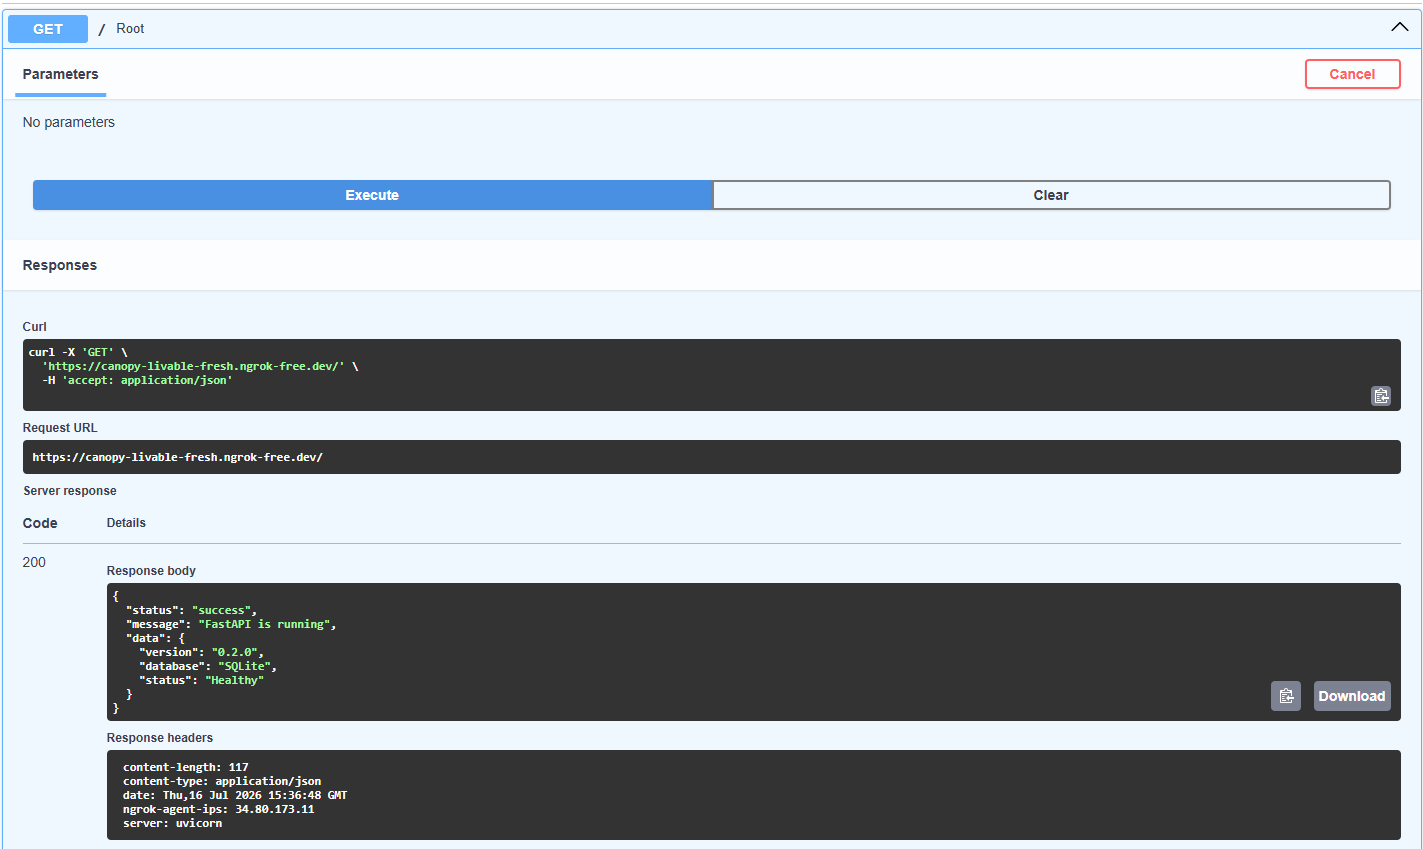

### Test 1: Root API

Endpoint:

GET /

Purpose:

Verify FastAPI server status.

Result:

API returned successful response with application status Healthy.